### Mechine Learning project

In [29]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import silhouette_score

In [30]:
# Part1: Data Preprocessing

# task_mode: 
# "early" removes potential leakage semester-performance features;
# "full" keeps all features.
task_mode = "full"

df_raw = pd.read_csv("data/data.csv", sep=";")
df_raw.columns = df_raw.columns.str.strip()

# 1) Missing values: add missing indicators + fill missing values
missing_cols = df_raw.columns[df_raw.isna().any()].tolist()
for col in missing_cols:
    df_raw[f"{col}_missing"] = df_raw[col].isna().astype(int)

num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_raw.select_dtypes(exclude=[np.number]).columns.tolist()

for col in num_cols:
    if df_raw[col].isna().any():
        df_raw[col] = df_raw[col].fillna(df_raw[col].median())

for col in cat_cols:
    if df_raw[col].isna().any():
        mode_val = df_raw[col].mode(dropna=True)
        fill_val = mode_val.iloc[0] if not mode_val.empty else "Missing"
        df_raw[col] = df_raw[col].fillna(fill_val)

# 2) Further processing
target_col = "Target"
X = df_raw.drop(columns=[target_col]).copy()
y = df_raw[target_col].copy()

# 2.1 Leakage control for early-stage prediction
leakage_keywords = ["approved", "grade", "evaluations", "credited", "without evaluations"]
leakage_cols = [c for c in X.columns if any(k in c.lower() for k in leakage_keywords)]
if task_mode == "early":
    X = X.drop(columns=leakage_cols, errors="ignore")

# 2.2 Treat coded categorical integers as categorical before one-hot
coded_categorical_cols = [
    "Marital status", "Application mode", "Application order", "Course",
    "Daytime/evening attendance", "Previous qualification", "Nacionality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced",
    "Educational special needs", "Debtor", "Tuition fees up to date",
    "Gender", "Scholarship holder", "International"
]
coded_categorical_cols = [c for c in coded_categorical_cols if c in X.columns]

for c in coded_categorical_cols:
    X[c] = X[c].astype("category")

# Keep boolean indicator for numeric binary columns not already converted
num_cols_X = X.select_dtypes(include=[np.number]).columns.tolist()
binary_numeric_cols = [
    c for c in num_cols_X if set(X[c].dropna().unique()).issubset({0, 1})
]
for c in binary_numeric_cols:
    X[c] = X[c].astype(bool)

# One-hot encode features and target (if target is non-numeric)
X_processed = pd.get_dummies(X, drop_first=False, dtype=int)
if not np.issubdtype(y.dtype, np.number):
    y_processed = pd.get_dummies(y, prefix="Target", dtype=int)
else:
    y_processed = y

# 2.3 Class-imbalance quick check
target_pct = y.value_counts(normalize=True) * 100

# 2.4 Analyze if feature standardization is needed
num_cols_processed = X_processed.select_dtypes(include=[np.number]).columns.tolist()
binary_cols_processed = [
    c for c in num_cols_processed if set(X_processed[c].dropna().unique()).issubset({0, 1})
]
non_binary_cols_processed = [c for c in num_cols_processed if c not in binary_cols_processed]

if len(non_binary_cols_processed) > 1:
    stds = X_processed[non_binary_cols_processed].std(ddof=0)
    positive_stds = stds[stds > 0]
    if len(positive_stds) > 1:
        scale_ratio = positive_stds.max() / positive_stds.min()
    else:
        scale_ratio = 1.0
else:
    scale_ratio = 1.0

# Heuristic: if scale ratio is large, standardization is recommended
need_standardize = scale_ratio >= 10

X_standardized = X_processed.copy()
if non_binary_cols_processed:
    scaler = StandardScaler()
    X_standardized[non_binary_cols_processed] = scaler.fit_transform(
        X_standardized[non_binary_cols_processed]
    )

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns with missing values: {len(missing_cols)}")
print(f"task_mode: {task_mode} | removed leakage cols: {len(leakage_cols) if task_mode == 'early' else 0}")
print(f"Coded categorical cols used: {len(coded_categorical_cols)}")
print(f"Features before encoding: {X.shape}, after encoding: {X_processed.shape}")
print("Target distribution (%):")
print(target_pct.round(2))

print("\nStandardization Analysis: ")
print(f"Non-binary numeric features: {len(non_binary_cols_processed)}")
print(f"Scale ratio (max_std/min_std among non-binary features): {scale_ratio:.2f}")
print(f"Need standardization (heuristic >= 10): {need_standardize}")

Raw dataset shape: (4424, 37)
Columns with missing values: 0
task_mode: full | removed leakage cols: 0
Coded categorical cols used: 18
Features before encoding: (4424, 36), after encoding: (4424, 262)
Target distribution (%):
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

Standardization Analysis: 
Non-binary numeric features: 18
Scale ratio (max_std/min_std among non-binary features): 20.96
Need standardization (heuristic >= 10): True


Current task_mode from Part1: full

Part2 Scaling Strategy Comparison: 
                              strategy  LDA_silhouette  tSNE_silhouette  best_perplexity
              No scaling (X_processed)          0.2593           0.0199               50
Scale non-binary only (X_standardized)          0.2593           0.0247               50

Part2 Standardization Conclusion: 
Scaled vs no-scale LDA gain: -0.0000
Scaled vs no-scale t-SNE gain: +0.0048
Chosen strategy for final figure: Scale non-binary only (X_standardized)


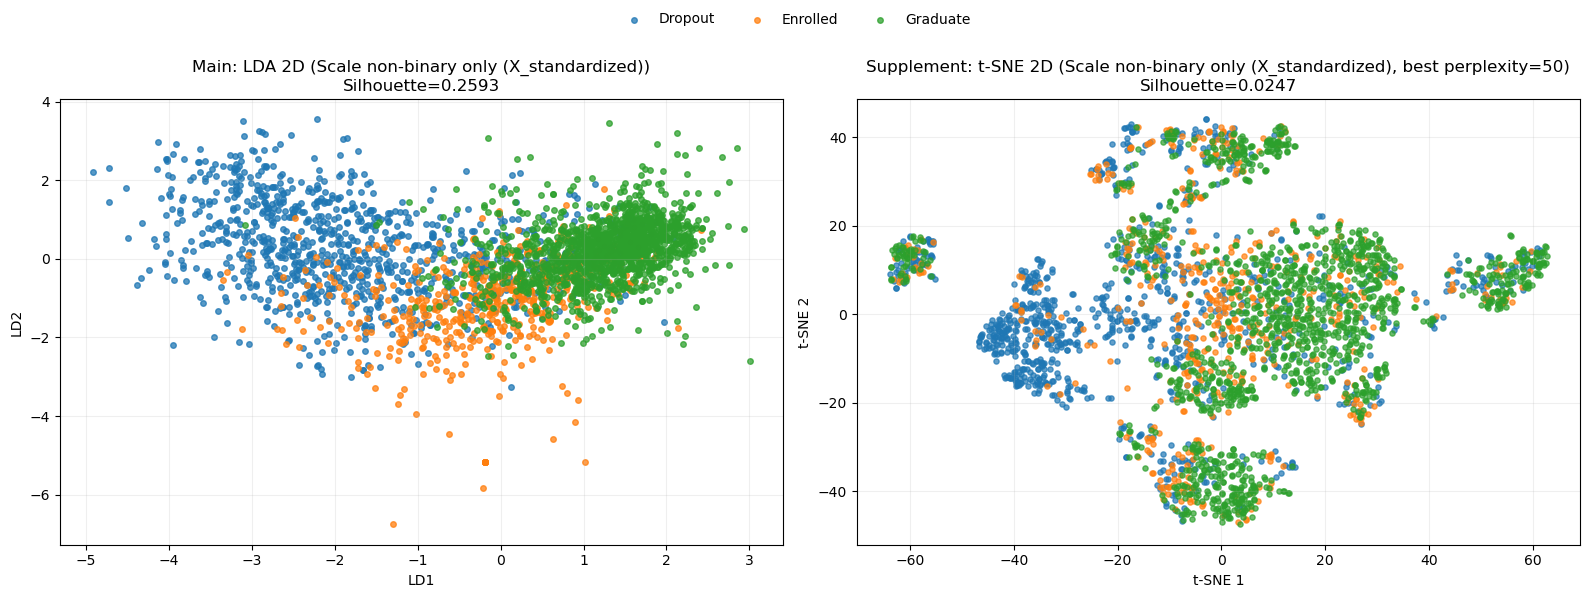


Final Decision:
Samples used: 3000
Chosen strategy: Scale non-binary only (X_standardized)
LDA silhouette: 0.2593
t-SNE silhouette: 0.0247 | best perplexity=50


In [31]:
# Part2: Visualization + standardization suitability analysis

print(f"Current task_mode from Part1: {task_mode}")

# ---- Data from Part1 ----
X_base = X_processed.copy()
y_label = y.copy() if isinstance(y, pd.Series) else pd.Series(y, name="Target")

le = LabelEncoder()
y_encoded = le.fit_transform(y_label)
class_names = list(le.classes_)

# Optional sampling for speed and clearer scatter plots
max_points = 3000
if len(X_base) > max_points:
    sample_idx = X_base.sample(n=max_points, random_state=42).index
    X_base = X_base.loc[sample_idx]
    y_label = y_label.loc[sample_idx]
    y_encoded = le.transform(y_label)

# Keep only two strategies
X_no_scale = X_base.copy()

if "X_standardized" in globals():
    X_selective_scaled = X_standardized.loc[X_base.index].copy()
else:
    # Fallback: standardize only non-binary columns
    X_selective_scaled = X_base.copy()
    num_cols_base = X_selective_scaled.select_dtypes(include=[np.number]).columns.tolist()
    binary_cols_base = [
        c for c in num_cols_base if set(X_selective_scaled[c].dropna().unique()).issubset({0, 1})
    ]
    non_binary_cols_base = [c for c in num_cols_base if c not in binary_cols_base]
    if non_binary_cols_base:
        scaler_fallback = StandardScaler()
        X_selective_scaled[non_binary_cols_base] = scaler_fallback.fit_transform(
            X_selective_scaled[non_binary_cols_base]
        )

strategies = {
    "No scaling (X_processed)": X_no_scale,
    "Scale non-binary only (X_standardized)": X_selective_scaled
}

candidate_perp = [10, 20, 30, 40, 50]
candidate_perp = [p for p in candidate_perp if p < len(X_base)]

def evaluate_strategy(X_input, y_input, perps):
    emb_lda_local = LDA(n_components=2).fit_transform(X_input, y_input)
    sil_lda_local = silhouette_score(emb_lda_local, y_input)

    best_perp_local = None
    best_tsne_sil_local = -np.inf
    best_emb_tsne_local = None

    for p in perps:
        emb_tmp = TSNE(
            n_components=2,
            perplexity=p,
            learning_rate="auto",
            init="pca",
            random_state=42
        ).fit_transform(X_input)
        sil_tmp = silhouette_score(emb_tmp, y_input)
        if sil_tmp > best_tsne_sil_local:
            best_tsne_sil_local = sil_tmp
            best_perp_local = p
            best_emb_tsne_local = emb_tmp

    return {
        "emb_lda": emb_lda_local,
        "sil_lda": float(sil_lda_local),
        "emb_tsne": best_emb_tsne_local,
        "sil_tsne": float(best_tsne_sil_local),
        "best_perp": int(best_perp_local)
    }

strategy_results = {}
for name, X_input in strategies.items():
    strategy_results[name] = evaluate_strategy(X_input, y_encoded, candidate_perp)

results_df = pd.DataFrame([
    {
        "strategy": name,
        "LDA_silhouette": strategy_results[name]["sil_lda"],
        "tSNE_silhouette": strategy_results[name]["sil_tsne"],
        "best_perplexity": strategy_results[name]["best_perp"]
    }
    for name in strategies.keys()
])
results_df = results_df.sort_values(
    by=["LDA_silhouette", "tSNE_silhouette"],
    ascending=False
).reset_index(drop=True)

baseline_name = "No scaling (X_processed)"
scaled_name = "Scale non-binary only (X_standardized)"

baseline_lda = strategy_results[baseline_name]["sil_lda"]
baseline_tsne = strategy_results[baseline_name]["sil_tsne"]
scaled_lda = strategy_results[scaled_name]["sil_lda"]
scaled_tsne = strategy_results[scaled_name]["sil_tsne"]

# Final rule requested: choose strategy with larger t-SNE silhouette
if scaled_tsne > baseline_tsne:
    best_strategy = scaled_name
else:
    best_strategy = baseline_name

best_metrics = strategy_results[best_strategy]

print("\nPart2 Scaling Strategy Comparison: ")
print(results_df.round(4).to_string(index=False))
print("\nPart2 Standardization Conclusion: ")
print(f"Scaled vs no-scale LDA gain: {scaled_lda - baseline_lda:+.4f}")
print(f"Scaled vs no-scale t-SNE gain: {scaled_tsne - baseline_tsne:+.4f}")
print(f"Chosen strategy for final figure: {best_strategy}")

# Use the chosen strategy for final figure
emb_lda = best_metrics["emb_lda"]
emb_tsne = best_metrics["emb_tsne"]
sil_lda = best_metrics["sil_lda"]
best_tsne_sil = best_metrics["sil_tsne"]
best_perp = best_metrics["best_perp"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cls in class_names:
    m = (y_label.values == cls)
    axes[0].scatter(emb_lda[m, 0], emb_lda[m, 1], s=16, alpha=0.75, label=str(cls))
axes[0].set_title(f"Main: LDA 2D ({best_strategy})\nSilhouette={sil_lda:.4f}")
axes[0].set_xlabel("LD1")
axes[0].set_ylabel("LD2")
axes[0].grid(alpha=0.2)

for cls in class_names:
    m = (y_label.values == cls)
    axes[1].scatter(emb_tsne[m, 0], emb_tsne[m, 1], s=14, alpha=0.7, label=str(cls))
axes[1].set_title(
    f"Supplement: t-SNE 2D ({best_strategy}, best perplexity={best_perp})\nSilhouette={best_tsne_sil:.4f}"
)
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(class_names), frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print("\nFinal Decision:")
print(f"Samples used: {len(X_base)}")
print(f"Chosen strategy: {best_strategy}")
print(f"LDA silhouette: {sil_lda:.4f}")
print(f"t-SNE silhouette: {best_tsne_sil:.4f} | best perplexity={best_perp}")